# VEP distributions

In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import seaborn as sns
import matplotlib.pyplot as plt
import pooch
import pandas as pd
from tqdm import tqdm

import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.ESM as ESM
import src.ESM_predict as ESMp
import src.gprofiler as gp
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.proteingym as pg 
import src.ensembl_rest as er
import src.biopython as bp
import src.analysis.distributions as db

pd.set_option('display.max_columns', None)

## Import VEP data

In [ ]:
vep_files = va.list_vep_files(as_df=True)

In [ ]:
# Focus on one model for the main plots
model_name = "esm2_t33_650M_UR50D"

vep_df = va.merge_vep(add_metadata=True, 
                      scoring_strategy=["masked-marginals"], 
                      vep_files=vep_files.loc[vep_files['model_location']==model_name]
                           )
vep_df.head() 

### VEP modality plots

Within each protein, capture the modality of their distributions.

In [ ]:
sample = [6.23, 5.58, 7.06, 6.42, 5.20]  # one-mile run times (minutes)
from scipy import stats
res = stats.ecdf(sample)
res.cdf.quantiles
res.cdf.evaluate(sample)

array([0.6, 0.4, 1. , 0.8, 0.2])

,x,ecdf,kde,n_peaks,n_samples,x_min,x_max,x_range,x_mean,x_std,x_var,x_median
0,-2.598999,0.083333,0.000022,4,12,-2.598999,-0.989389,1.609609,-2.234221,0.415678,0.172788,-2.244844
1,-2.582740,0.250000,0.000465,4,12,-2.598999,-0.989389,1.609609,-2.234221,0.415678,0.172788,-2.244844
2,-2.566481,0.250000,0.006037,4,12,-2.598999,-0.989389,1.609609,-2.234221,0.415678,0.172788,-2.244844
3,-2.550223,0.250000,0.050117,4,12,-2.598999,-0.989389,1.609609,-2.234221,0.415678,0.172788,-2.244844
4,-2.533964,0.250000,0.268066,4,12,-2.598999,-0.989389,1.609609,-2.234221,0.415678,0.172788,-2.244844


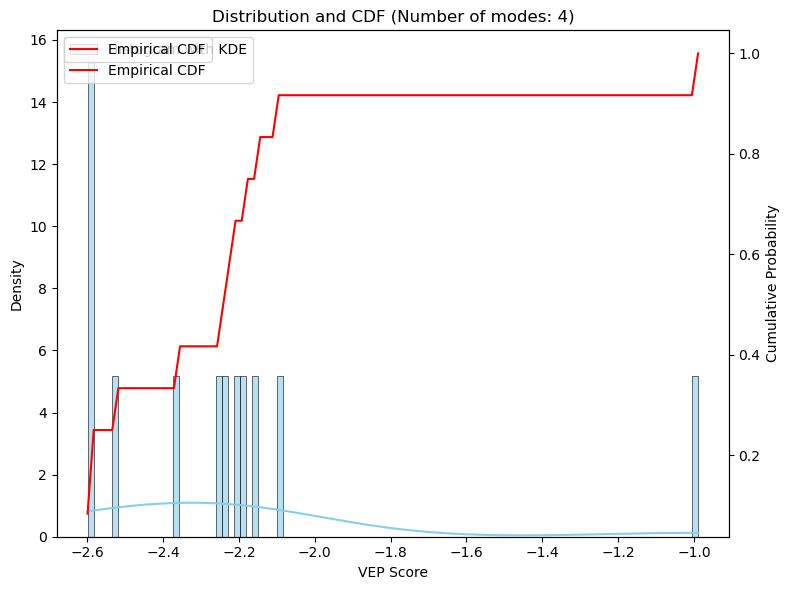

In [ ]:
i = 2
dat = vep_df.dropna(subset=['VEP']).loc[(vep_df['model_location']==vep_df['model_location'].unique()[0]) &\
                                        (vep_df['protein']==vep_df['protein'].unique()[i]) &\
                                        (vep_df['scoring_strategy']=='masked-marginals')]
dat = dat.loc[dat['mutant'] == dat['mutant'].unique()[10]]
# utils.get_kde(dat['VEP'],
#                   title=f"Protein: {dat['protein'].tolist()[0]}, Scoring strategy: {dat['scoring_strategy'].tolist()[0]}",
#                   plot=True)

ecdf_df =utils.get_ecdf(dat['VEP'],
                #   title=f"Protein: {dat['protein'].tolist()[0]}, Scoring strategy: {dat['scoring_strategy'].tolist()[0]}",
                  return_df=True,
                  grid_points=100,
                  plot=True)
ecdf_df.head()
  

In [ ]:
from tqdm import tqdm

vep_ecdf_path = 'results/vep_ecdf.tsv.gz'
force = True
if os.path.exists(vep_ecdf_path) and not force:
    print("Loading cached ECDF data")
    vep_ecdf = pd.read_csv(vep_ecdf_path, sep='\t')
else:
    
    groupby_cols = ['model_location', 'protein','scoring_strategy','mutant','clinsig']
    vep_df['n_haplotypes'] = vep_df.groupby(groupby_cols)['haplotype'].transform('nunique')
    
    tqdm.pandas(desc="Estimating modality")
    vep_ecdf = vep_df.dropna(subset=['VEP']).sort_values(['VEP']).groupby(groupby_cols+['n_haplotypes'])['VEP'].progress_apply(
        utils.get_ecdf, 
        return_df=True, 
        error=False
    ).reset_index()
    vep_ecdf.rename(columns={'level_6':'grid_index'}, inplace=True)
    vep_ecdf['id'] = vep_ecdf[groupby_cols].astype(str).agg('_'.join, axis=1)

    # vep_ecdf.to_csv(vep_ecdf_path, index=False, sep='\t')

print(vep_ecdf.shape)
vep_ecdf.head()

Estimating modality:   2%|▏         | 763/36074 [00:08<07:01, 83.75it/s]/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/KDEpy/bw_selection.py:79: RuntimeWarning: divide by zero encountered in scalar divide
  time = np.power((2 * const * K0 / (N * f)), (2.0 / (3.0 + 2.0 * s)))
/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/KDEpy/bw_selection.py:85: RuntimeWarning: divide by zero encountered in power
  t_opt = np.power(2 * N * np.sqrt(np.pi) * f, -2.0 / 5)
Estimating modality:   7%|▋         | 2542/36074 [00:21<05:56, 94.07it/s] /home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/KDEpy/bw_selection.py:85: RuntimeWarning: divide by zero encountered in power
  t_opt = np.power(2 * N * np.sqrt(np.pi) * f, -2.0 / 5)
/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/KDEpy/bw_selection.py:79: RuntimeWarning: divide by zero encountered in scalar divide
  time = np.power((2 * const * K0 / (N * f)), (2.0 / (3.0 + 2.0 * s)))
Estimating modality:  11%|

(3523800, 20)


,model_location,protein,scoring_strategy,mutant,clinsig,n_haplotypes,grid_index,x,ecdf,kde,n_peaks,n_samples,x_min,x_max,x_range,x_mean,x_std,x_var,x_median,id
0,esm2_t33_650M_UR50D,NP_000007.1,masked-marginals,A113D,path,16,0,-5.800485,0.0625,2.220446e-16,6,16,-5.800485,-5.689598,0.110887,-5.748721,0.028002,0.000784,-5.757046,esm2_t33_650M_UR50D_NP_000007.1_masked-margina...
1,esm2_t33_650M_UR50D,NP_000007.1,masked-marginals,A113D,path,16,1,-5.799365,0.0625,2.220446e-16,6,16,-5.800485,-5.689598,0.110887,-5.748721,0.028002,0.000784,-5.757046,esm2_t33_650M_UR50D_NP_000007.1_masked-margina...
2,esm2_t33_650M_UR50D,NP_000007.1,masked-marginals,A113D,path,16,2,-5.798245,0.0625,2.220446e-16,6,16,-5.800485,-5.689598,0.110887,-5.748721,0.028002,0.000784,-5.757046,esm2_t33_650M_UR50D_NP_000007.1_masked-margina...
3,esm2_t33_650M_UR50D,NP_000007.1,masked-marginals,A113D,path,16,3,-5.797124,0.0625,1.889543e-06,6,16,-5.800485,-5.689598,0.110887,-5.748721,0.028002,0.000784,-5.757046,esm2_t33_650M_UR50D_NP_000007.1_masked-margina...
4,esm2_t33_650M_UR50D,NP_000007.1,masked-marginals,A113D,path,16,4,-5.796004,0.0625,5.945866e+01,6,16,-5.800485,-5.689598,0.110887,-5.748721,0.028002,0.000784,-5.757046,esm2_t33_650M_UR50D_NP_000007.1_masked-margina...


count    3.523800e+06
mean     5.535133e+00
std      1.974668e+00
min      1.000000e+00
25%      4.000000e+00
50%      6.000000e+00
75%      7.000000e+00
max      1.300000e+01
Name: n_peaks, dtype: float64


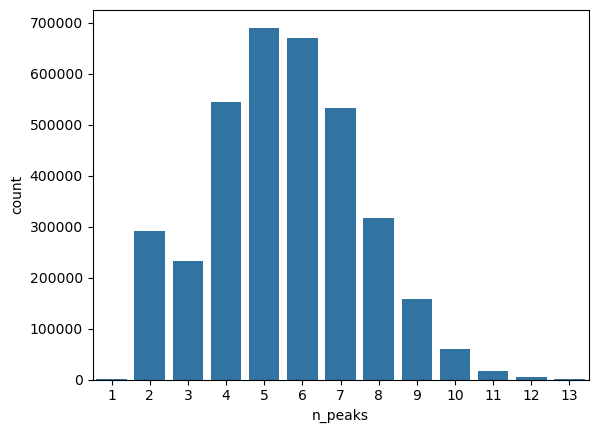

In [ ]:
print(vep_ecdf['n_peaks'].describe())

import matplotlib.pyplot as plt
import seaborn as sns
sns.barplot(data=vep_ecdf['n_peaks'].value_counts())
plt.show()


#### Run UMAP on VEP ECDF 

In [ ]:
# Create a matrix with both ECDF values and VEP statistics
vep_ecdf_pivot = vep_ecdf.pivot_table(
    index=['id','model_location', 'protein', 
           'scoring_strategy', 'mutant', 'clinsig',
             'n_haplotypes', 'n_peaks',
           'x_min', 'x_max','x_range', 'x_std', 'x_var'],
    columns='grid_index',
    values='ecdf'
)

# Run UMAP
model, embedding, nan_indices = utils.run_umap(vep_ecdf_pivot, 
                                               filter=False)

# Create a dataframe with the UMAP embedding
ecdf_umap_df = pd.DataFrame(embedding, 
                            index=vep_ecdf_pivot.index, 
                            columns=[f'UMAP_{i+1}' for i in range(embedding.shape[1])]
                            ).reset_index()
ecdf_umap_df['x_range_log'] = np.log2(ecdf_umap_df['x_range'])


Running UMAP


/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(n_jobs=1, random_state=42, verbose=True)
Tue May 13 10:51:41 2025 Construct fuzzy simplicial set
Tue May 13 10:51:41 2025 Finding Nearest Neighbors
Tue May 13 10:51:41 2025 Building RP forest with 14 trees
Tue May 13 10:51:45 2025 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	Stopping threshold met -- exiting after 3 iterations
Tue May 13 10:51:55 2025 Finished Nearest Neighbor Search
Tue May 13 10:51:57 2025 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Tue May 13 10:52:48 2025 Finished embedding


/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


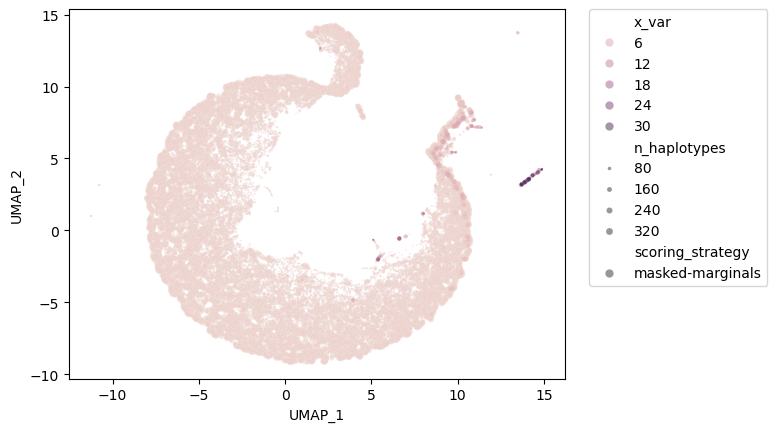

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=ecdf_umap_df.sort_values('x_var', ascending=True),
                x='UMAP_1',
                y='UMAP_2',
                size='n_haplotypes',
                sizes=(1, 30),
                alpha=0.5,
                hue='x_var',
                style='scoring_strategy',
                )
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)


In [ ]:
import plotly.express as px

fig = px.scatter(ecdf_umap_df.sort_values('x_range', ascending=True),
                 x='UMAP_1',
                 y='UMAP_2',
                 color='x_range_log',
                 size='n_haplotypes',
                 size_max=5,
                 symbol='scoring_strategy',
                 hover_data=['model_location', 'protein', 'scoring_strategy'], 
                 hover_name='protein',
                 opacity=0.75)
# Reduce the height of the color bar
fig.update_layout(coloraxis_colorbar=dict(len=0.6))  # Reduce colorbar height to 60% of default
# Remove marker border
fig.update_traces(marker=dict(line=dict(width=0)))
fig.show()

#### Run hierarchical clustering on VEP ECDF 

,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,haplotype_sequence,reference_sequence_len,haplotype_sequence_len,haplotype_sequence_len_pct,mutant_out_of_frame,diff_benign,diff_possibly damaging,diff_probably damaging,diff_unknown,n_haplotypes
6644,ENSP00000262186:REF,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,L1045F,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-3.655681,masked-marginals,True,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947347,67473,G,A,.,PASS,67473,7:150947347,A,3757,NM_000238.4,Transcript,missense_variant,3541,3133,1045,L/F,Ctc/Ttc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000238.4:c.3133C>T,NP_000229.1:p.Leu1045Phe,-,NaN,0.00000,78369,"MedGen:CN230736|EFO:EFO_0004269,Human_Phenotyp...",Cardiovascular_phenotype|Cardiac_arrhythmia|Co...,NC_000007.14:g.150947347G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,SO:0001583|missense_variant,1,199473025.0,NaN,ClinGen:CA008015,NaN,NaN,NaN,NaN,NaN,-6.731237,-0.021689,6,benign,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,1159,1159.0,1.0,False,0.0,0.0,0.0,0.0,45
6645,ENSP00000262186:REF,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,D1003Y,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-1.646006,masked-marginals,True,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947473,200516,C,A,.,PASS,200516,7:150947473,A,3757,NM_000238.4,Transcript,missense_variant,3415,3007,1003,D/Y,Gac/Tac,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.3007G>T,NP_000229.1:p.Asp1003Tyr,-,NaN,NaN,197155,MedGen:CN517202,not_provided,NC_000007.14:g.150947473C>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,794728402.0,NaN,ClinGen:CA007791,NaN,NaN,NaN,NaN,NaN,-2.509515,-0.039753,6,likely_path,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,1159,1159.0,1.0,False,0.0,0.0,0.0,0.0,45
6646,ENSP00000262186:REF,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,N996I,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-4.525650,masked-marginals,True,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947493,67458,T,A,.,PASS,67458,7:150947493,A,3757,NM_000238.4,Transcript,missense_variant,3395,2987,996,N/I,aAc/aTc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000238.4:c.2987A>T,NP_000229.1:p.Asn996Ile,-,NaN,NaN,78354,"MONDO:MONDO:0019171,MedGen:C1141890,OMIM:PS192...",Congenital_long_QT_syndrome|not_provided|Long_...,NC_000007.14:g.150947493T>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,199473018.0,NaN,ClinGen:CA007728|UniProtKB:Q12809#VAR_068285,NaN,NaN,NaN,NaN,NaN,-5.869637,-0.057342,6,likely_path,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,1159,1159.0,1.0,False,0.0,0.0,0.0,0.0,45
6647,ENSP00000262186:REF,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,E978K,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-0.581127,masked-marginals,True,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,F

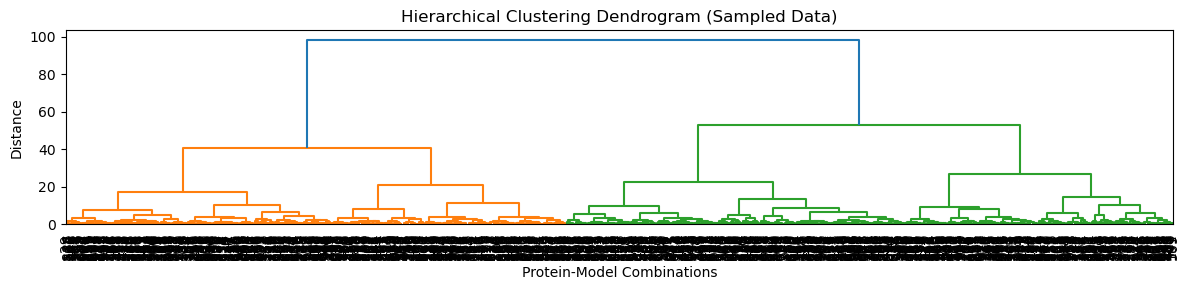

Number of clusters: 30
Cluster distribution: cluster
1     1858
2     1725
3     1043
4     2082
5      551
6     1137
7      732
8     1311
9     1108
10    2109
11    2608
12     619
13    1335
14     897
15    2077
16     678
17     420
18     455
19     803
20    1009
21    2452
22    1428
23     792
24    1874
25     806
26     808
27      83
28     335
29     918
30    1185
Name: count, dtype: int64
Cluster statistics:
grid_index   n_peaks                      n_haplotypes                
                mean median min max count         mean median min  max
cluster                                                               
1           6.031755    6.0   2  13  1858    66.766954   52.0   6  388
2           6.732174    7.0   2  12  1725    44.248116   34.0   6  388
3           5.511026    5.0   2  10  1043    78.161074   55.0   6  388
4           5.485110    5.0   2  11  2082    68.156580   53.0   9  388
5           5.134301    5.0   2  11   551    22.633394    9.0   3  388
6  

In [ ]:
# Perform hierarchical clustering on the VEP KDE data
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import numpy as np

n_clusters = 30  # You can adjust this based on the dendrogram


# Create a matrix with both ECDF values and VEP statistics
vep_ecdf_pivot = vep_ecdf.pivot_table(
    index=['id','model_location', 'protein', 
           'scoring_strategy', 'mutant', 'clinsig',
             'n_haplotypes', 'n_peaks',
           'x_min', 'x_max','x_range', 'x_std', 'x_var'],
    columns='grid_index',
    values='ecdf'
)


# Sample data if it's too large (for faster clustering)
n_samples = min(1000, len(vep_ecdf_pivot))
if len(vep_ecdf_pivot) > n_samples:
    # Use stratified sampling to maintain distribution
    sampled_indices = np.random.choice(
        len(vep_ecdf_pivot), 
        size=n_samples, 
        replace=False
    )
    data_for_clustering = vep_ecdf_pivot.iloc[sampled_indices]
else:
    data_for_clustering = vep_ecdf_pivot

# Perform hierarchical clustering (faster with reduced dataset)
Z = linkage(data_for_clustering, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 3))
dendrogram(Z, 
        #    truncate_mode='lastp',  # show only the last p merged clusters
           p=n_clusters,  # show only the last 30 merged clusters
           leaf_rotation=90.,
           leaf_font_size=10.)
plt.title('Hierarchical Clustering Dendrogram (Sampled Data)')
plt.xlabel('Protein-Model Combinations')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# Cut the dendrogram to get clusters
clusters = fcluster(Z, n_clusters, criterion='maxclust')

# Map clusters back to original data if sampled
if len(vep_ecdf_pivot) > n_samples:
    # Train a simple classifier to predict clusters for all data points
    from sklearn.neighbors import KNeighborsClassifier
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(data_for_clustering, clusters)
    all_clusters = knn.predict(vep_ecdf_pivot)
    vep_ecdf_pivot['cluster'] = all_clusters
else:
    vep_ecdf_pivot['cluster'] = clusters

print(f"Number of clusters: {n_clusters}")
print(f"Cluster distribution: {pd.Series(vep_ecdf_pivot['cluster']).value_counts().sort_index()}")

# Visualize clusters in UMAP space
groupby_cols = ['model_location', 'protein', 'scoring_strategy','mutant','n_haplotypes','n_peaks']
ecdf_umap_df['cluster'] = ecdf_umap_df.set_index(groupby_cols).index.map(
    vep_ecdf_pivot.reset_index().set_index(groupby_cols)['cluster']
)
 
# Analyze cluster characteristics
cluster_stats = vep_ecdf_pivot.reset_index().groupby('cluster').agg({
    'n_peaks': ['mean', 'median', 'min', 'max', 'count'],
    'n_haplotypes': ['mean', 'median', 'min', 'max']
})
print("Cluster statistics:")
print(cluster_stats)


/tmp/ipykernel_2078988/1686241159.py:148: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



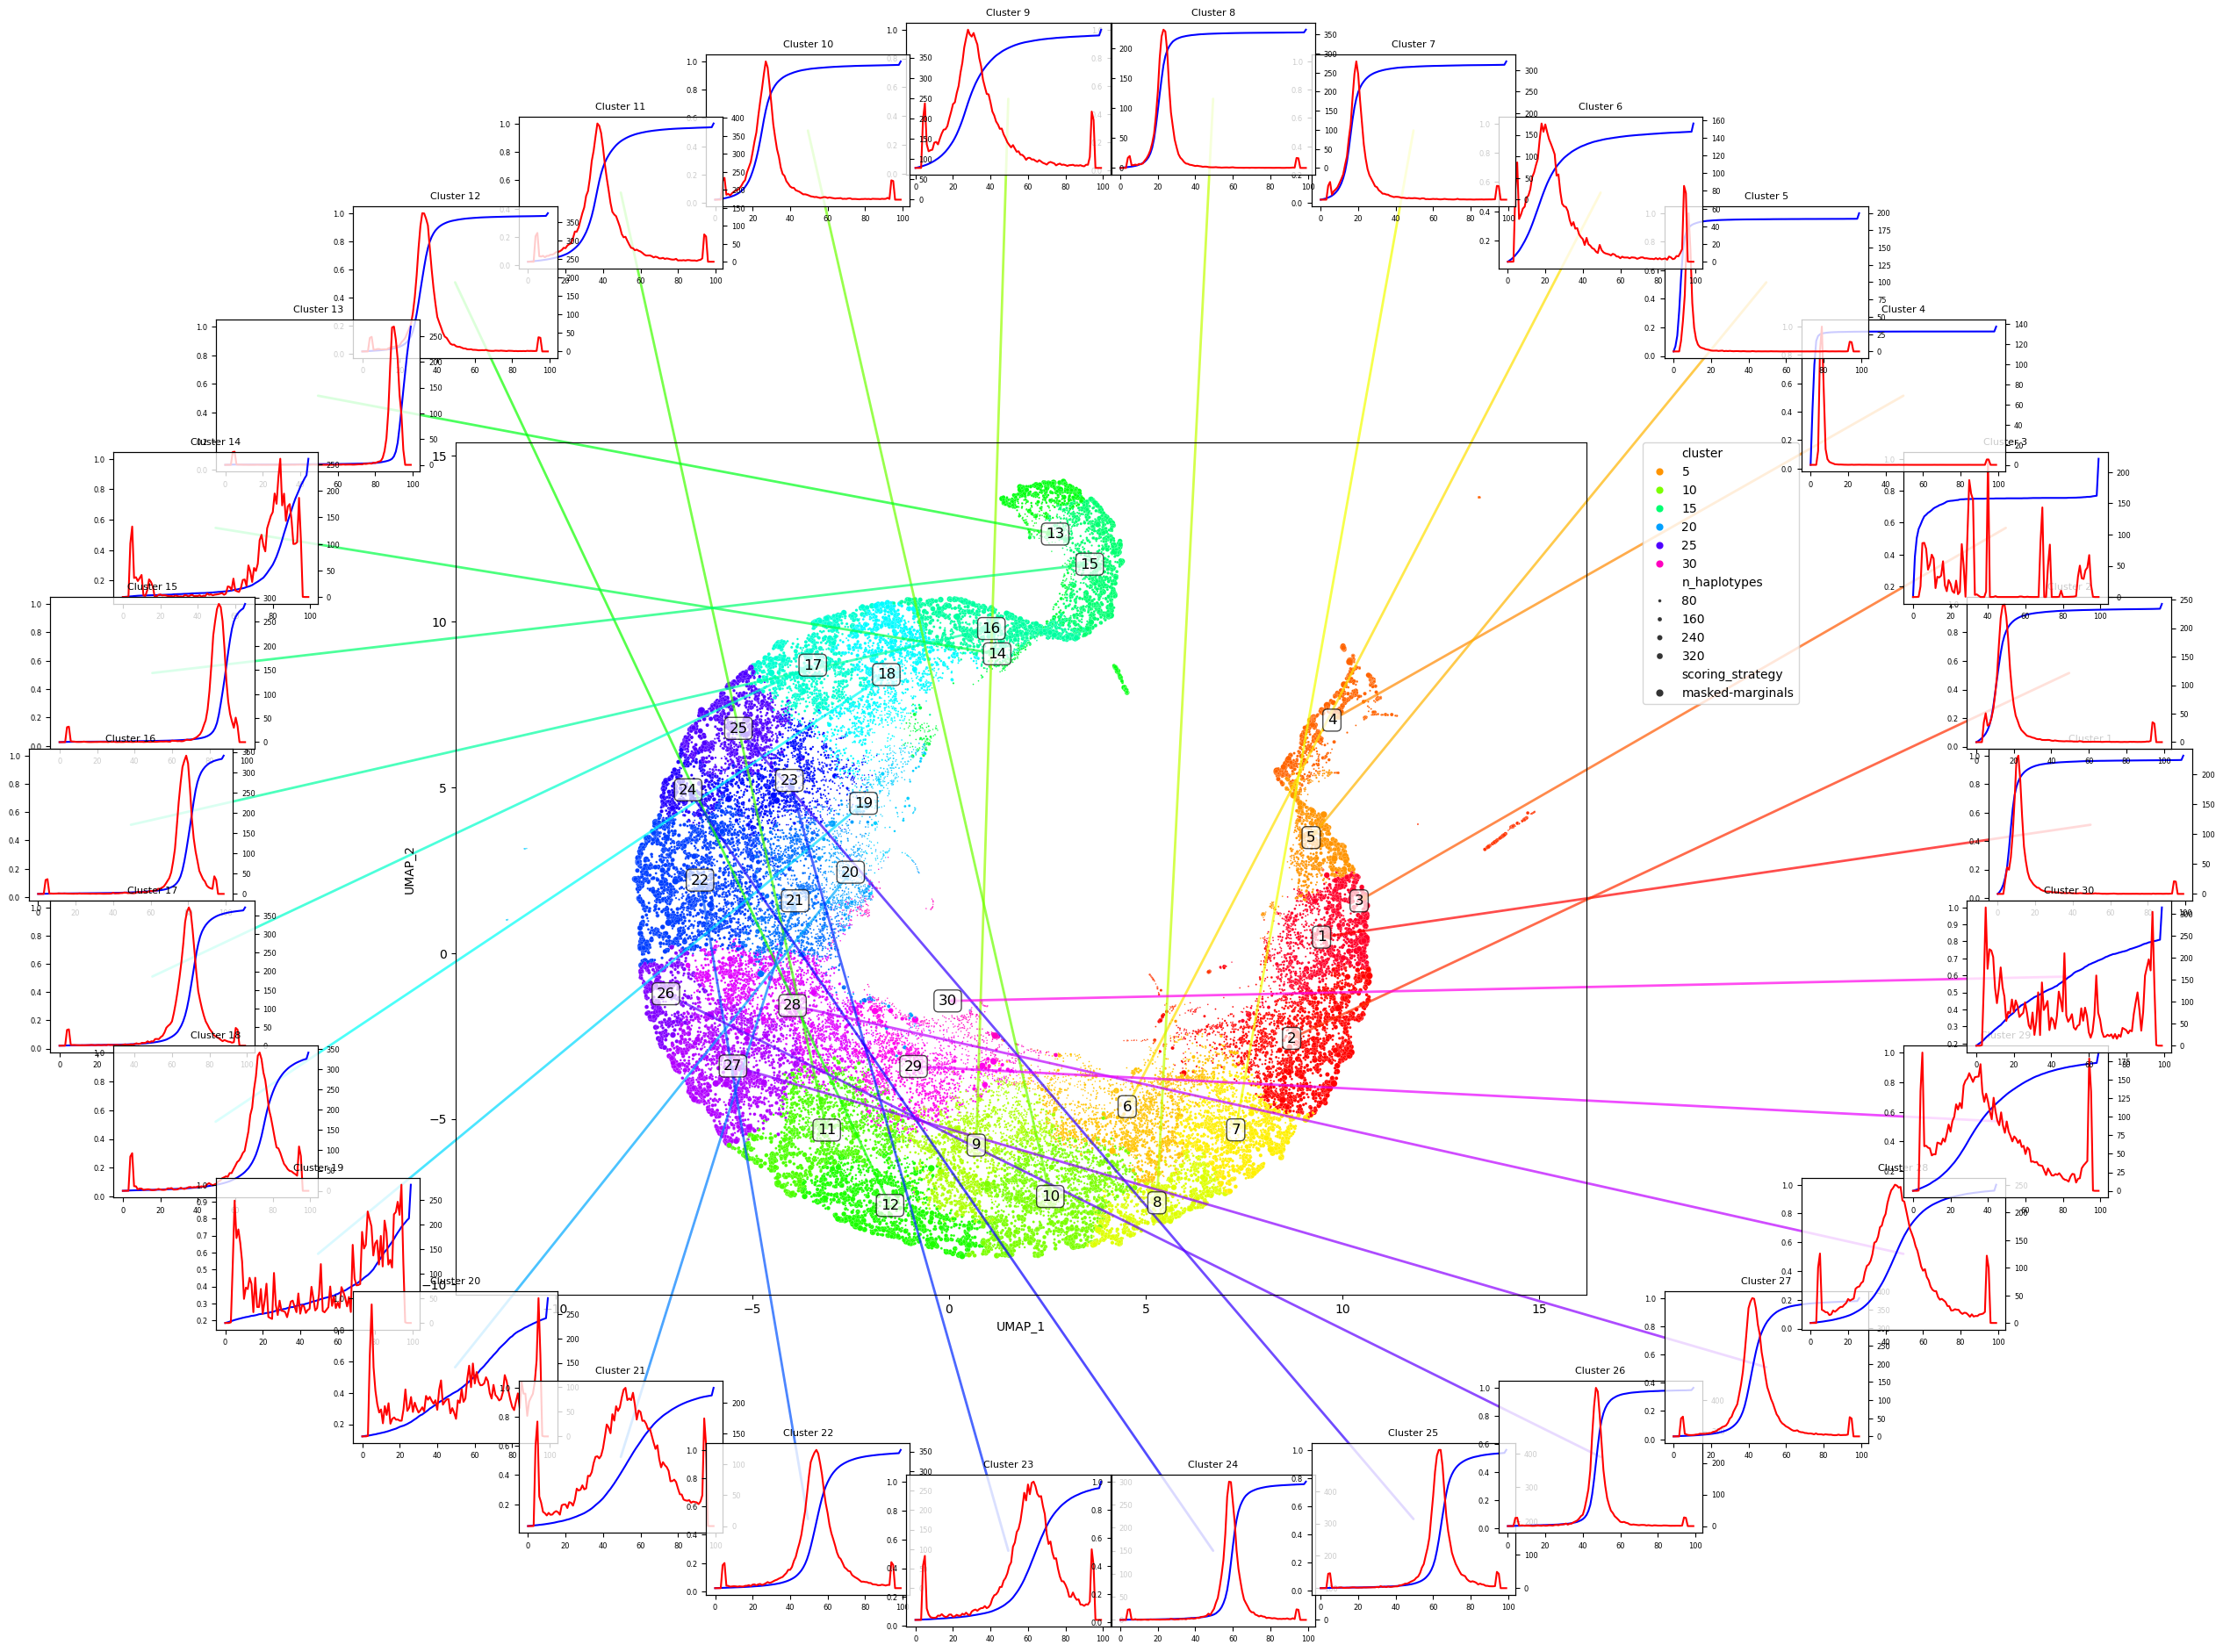

In [ ]:

# Example usage:
fig = create_cluster_distribution_plot(ecdf_umap_df, vep_ecdf, vep_ecdf_pivot, num_subplots=30, min_distance=0.8, connector_alpha=0.7)
plt.show() 

In [ ]:
ecdf_umap_df_path = 'results/vep_ecdf_umap.tsv.gz'
if os.path.exists(ecdf_umap_df_path) and 'ecdf_umap_df' not in locals():
    print("Loading cached ECDF UMAP data")
    ecdf_umap_df = pd.read_csv(ecdf_umap_df_path, sep='\t')
else:
    ecdf_umap_df.to_csv(ecdf_umap_df_path, sep='\t')


Loading cached ECDF UMAP data


#### Gprofiler enrichment of each VEP modality


In [ ]:
# Create a dictionary where keys are n_peaks and values are unique proteins
peak_protein_dict = {n_peak: list(set(proteins)) for n_peak, proteins in 
                     ecdf_umap_df.groupby(['n_peaks'])['protein'].apply(list).items()}

# Create a dictionary where keys are n_peaks and values are unique proteins
cluster_protein_dict = {cluster: list(set(proteins)) for cluster, proteins in 
                     ecdf_umap_df.groupby(['cluster'])['protein'].apply(list).items()}

ecdf_umap_df['x_var_quantile'] = pd.qcut(ecdf_umap_df['x_var'], q=10, labels=False)
variance_protein_dict = {x_var: list(set(proteins)) for x_var, proteins in 
                         ecdf_umap_df.groupby(['x_var_quantile'])['protein'].apply(list).items()}


In [ ]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)
gp_df = gp.profile(organism='hsapiens',
                   background=ecdf_umap_df['protein'].unique().tolist(),
                   query=variance_protein_dict
                   )
print(gp_df.shape)

(284, 14)


    source      native                                       name  \
0       HP  HP:0000006             Autosomal dominant inheritance   
1    GO:BP  GO:0050789           regulation of biological process   
2       HP  HP:0000006             Autosomal dominant inheritance   
3    GO:BP  GO:0050794             regulation of cellular process   
4       HP  HP:0000006             Autosomal dominant inheritance   
..     ...         ...                                        ...   
256     HP  HP:0025142                     Constitutional symptom   
258     TF   TF:M10111              Factor: ZF5; motif: NGAGCGCGC   
262     HP  HP:0003110           Abnormality of urine homeostasis   
264     HP  HP:0003110           Abnormality of urine homeostasis   
283     HP  HP:0034684  Abnormal enzyme concentration or activity   

          p_value  significant  \
0    1.820627e-12         True   
1    4.573907e-11         True   
2    5.664574e-11         True   
3    8.512743e-10         True   
4

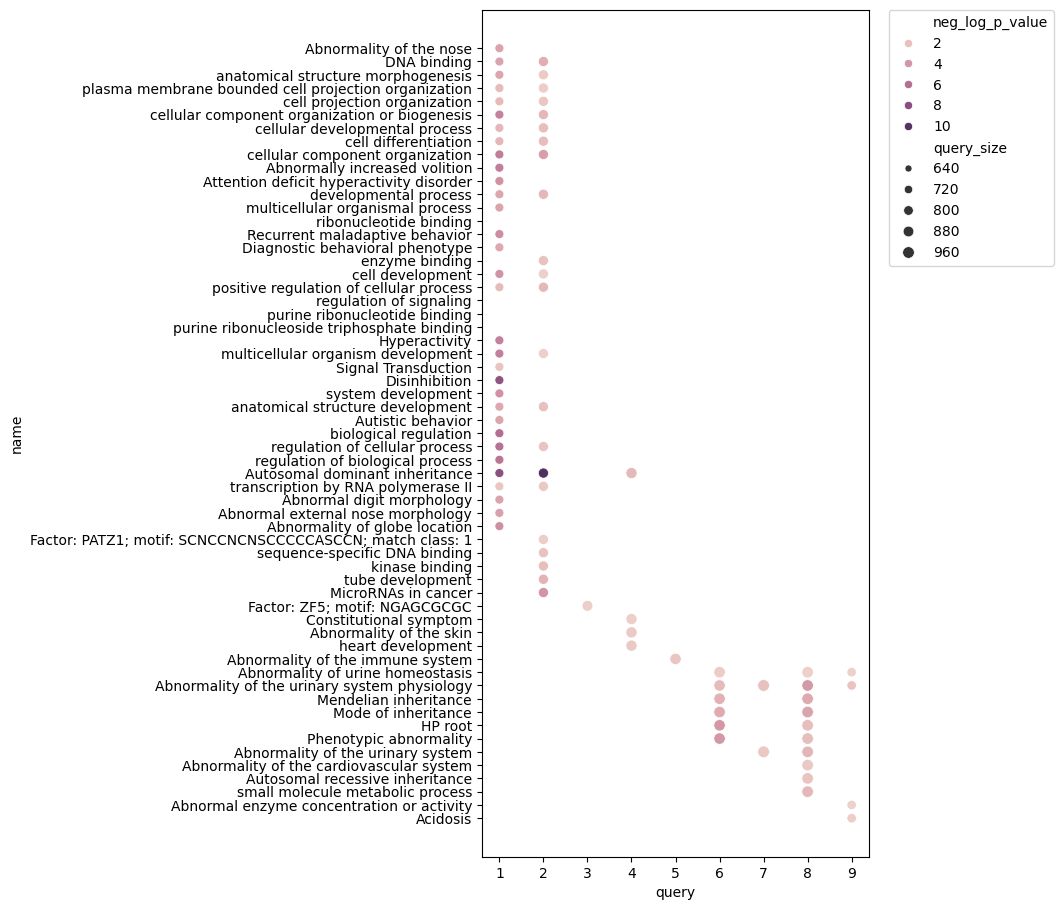

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
gp_df['query'] = gp_df['query'].astype(int).astype(str)
top_n = 20
if top_n is not None:
    gp_top = gp_df.groupby('query').head(top_n)
else:
    gp_top = gp_df

gp_df['neg_log_p_value'] = -np.log10(gp_df['p_value'])
print(gp_top)

plt.figure(figsize=(5, 11))
# Convert query groups to categorical with ordered categories to ensure proper ordering
ordered_queries = [str(i) for i in range(1, max(gp_df['query'].astype(int).unique())+1)]  
plot_data = gp_df[gp_df['name'].isin(gp_top['name'])].sort_values(['query','neg_log_p_value'])
plot_data['query'] = pd.Categorical(plot_data['query'], categories=ordered_queries, ordered=True)

sns.scatterplot(data=plot_data,
            x='query',
            y='name',
            hue='neg_log_p_value',
            size='query_size',
            )

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.show()



### Benign/Pathogenic Ratio

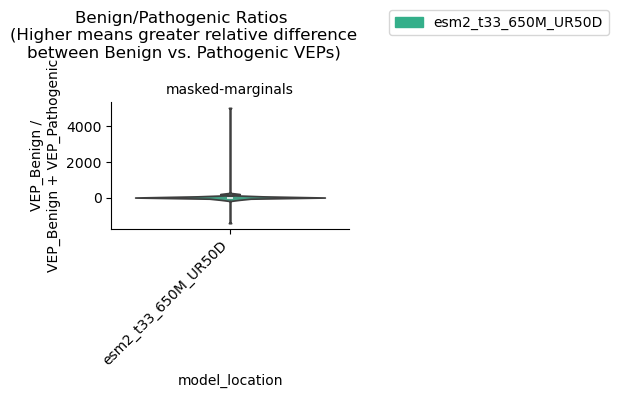

In [ ]:
vep_pbratios = va.plot_vep_bpratios(vep_df,
                                     y=['benign_path_ratio','benign_path_ratio_strict'][0]
                                     )